In [687]:
import cv2
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path().resolve().parent / 'data'
BBDD_DIR = DATA_DIR / 'BBDD'
QSD2 = DATA_DIR / 'qsd2_w2'

IMG_ID = '00001'

In [688]:
def show(*images, titles=None, size=3, cols=4):
    cols = min(cols, len(images))
    rows = -(-len(images) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows), squeeze=False)
    for ax in axes.flat[len(images):]:
        ax.axis('off')
    for i, (ax, im) in enumerate(zip(axes.flat, images)):
        if im.ndim == 2:
            ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        else:
            ax.imshow(im)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_color('blue')
            spine.set_linewidth(1.5)
        if titles:
            ax.set_title(titles[i])
    plt.tight_layout()
    plt.show()

def norm(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def inv(img):
    return 255 - norm(img)

In [689]:
img_orig = cv2.imread(QSD2 / (IMG_ID + '.jpg'))
h, w = img_orig.shape[:2]


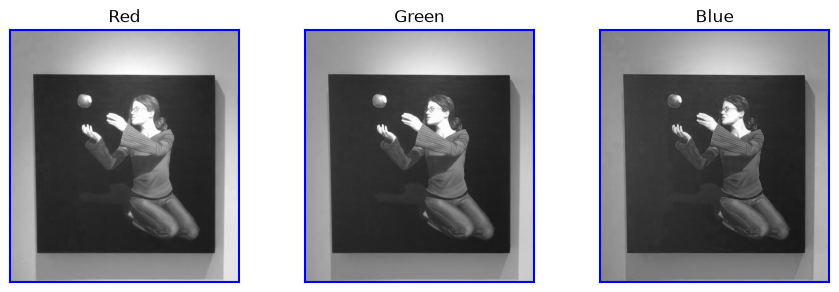

In [690]:
img = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
R, G, B = cv2.split(img)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

show(R, G, B, titles=['Red', 'Green', 'Blue'])

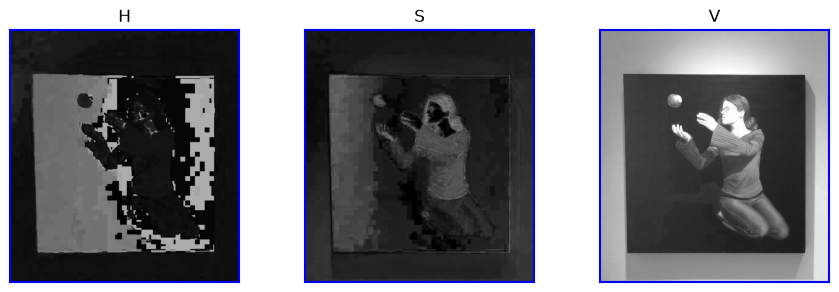

In [691]:
img = cv2.cvtColor(img_orig, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(img)

show(H, S, V, titles=['H', 'S', 'V'])

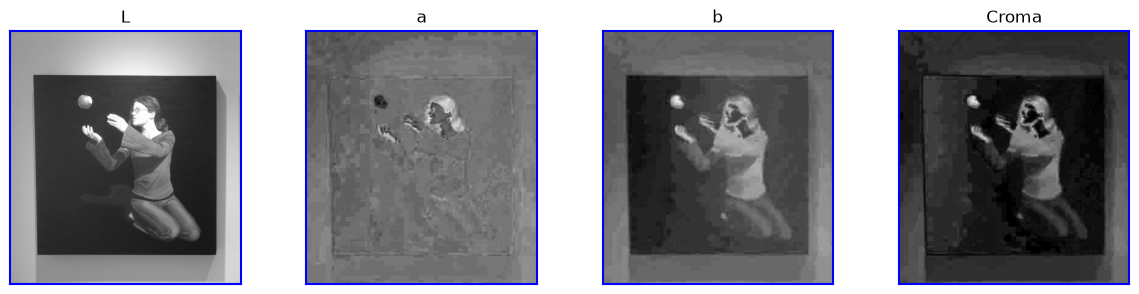

In [692]:
img = cv2.cvtColor(img_orig, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img)

a = a.astype(np.float32) - 128
b = b.astype(np.float32) - 128
croma = np.sqrt(a**2 + b**2)

a, b, croma = norm(a), norm(b), norm(croma)

show(L, a, b, croma, titles=['L', 'a', 'b', 'Croma'])

In [693]:
channel = croma

In [694]:
# median = cv2.medianBlur(channel, 3)

# show(channel, median, titles=['Channel', 'Median Filtered'])

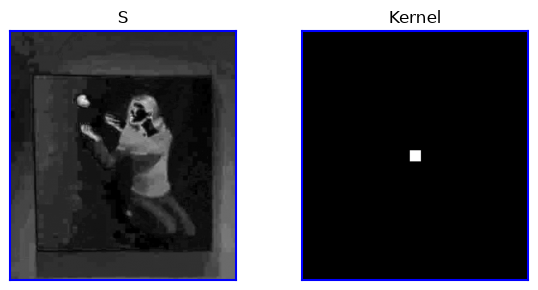

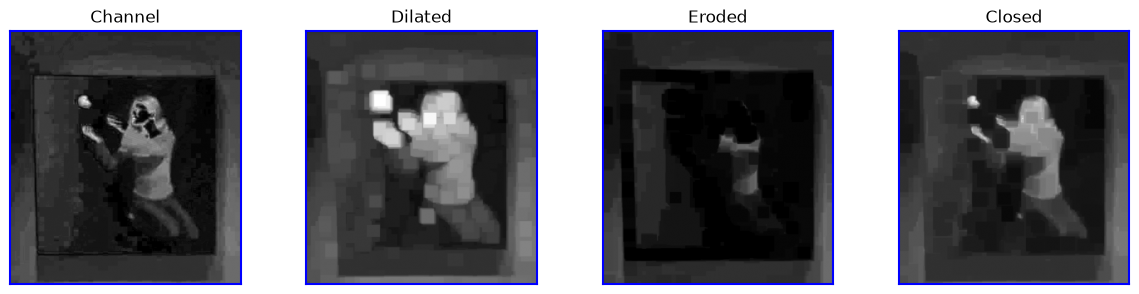

In [695]:
n = int(min(h,w) * 0.05)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (n,n))

y0 = h // 2 - n // 2
x0 = w // 2 - n // 2
empty = np.zeros_like(channel)
empty[y0:y0 + n, x0:x0 + n] = kernel * 255

show(channel, empty, titles=['S', 'Kernel'])

dilated = cv2.dilate(channel, kernel)
eroded = cv2.erode(channel, kernel)
closed = cv2.morphologyEx(channel, cv2.MORPH_CLOSE, kernel)

show(channel, dilated, eroded, closed, titles=['Channel', 'Dilated', 'Eroded', 'Closed'])

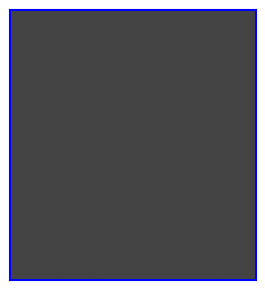

In [696]:
morph = closed

v = 10
border = np.zeros(morph.shape, bool)
border[:v, :] = border[-v:, :] = border[:, :v] = border[:, -v:] = True

border_mean = morph[border].mean()

empty = np.full_like(morph, int(border_mean))
show(empty)

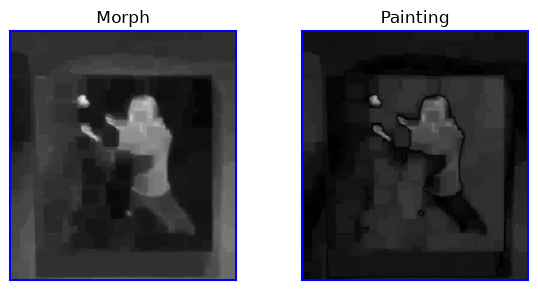

In [697]:
painting = np.abs(morph.astype(np.int16) - int(border_mean)).astype(np.uint8)

show(morph, painting, titles=['Morph', 'Painting'])

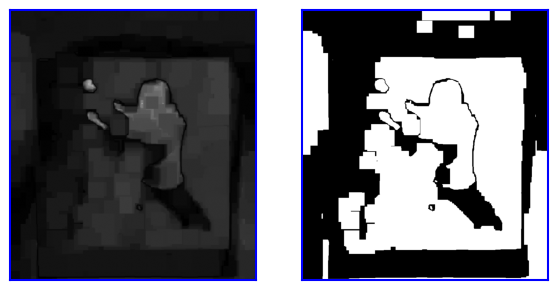

In [698]:
thr = (painting > 20).astype(np.uint8) * 255

show(painting, thr)

In [699]:
# t, thr = cv2.threshold(painting, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# show(painting, norm(thr), titles=['Gray', 'Thresholding'])

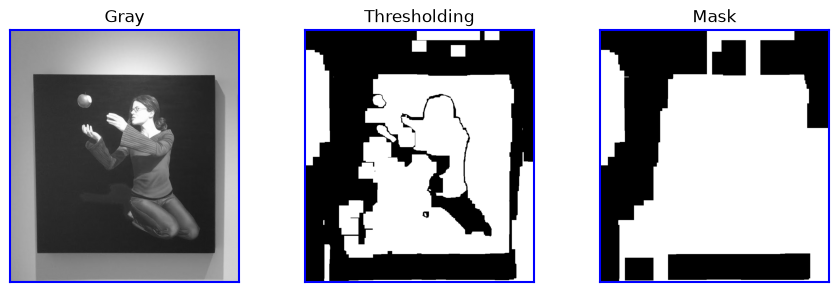

In [700]:
n = min(h,w)//10
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (n,n))

mask = cv2.morphologyEx(thr, cv2.MORPH_CLOSE, kernel)
show(gray, thr, mask, titles=['Gray', 'Thresholding', 'Mask'])

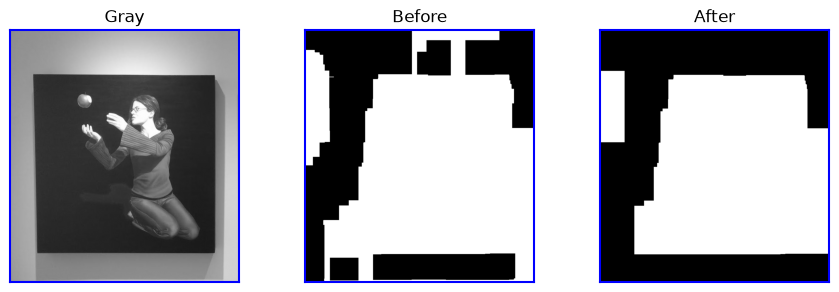

In [701]:
n = min(h,w)//5
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (n,n))

last_mask = mask.copy()
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
show(gray, last_mask, mask, titles=['Gray', 'Before', 'After'])

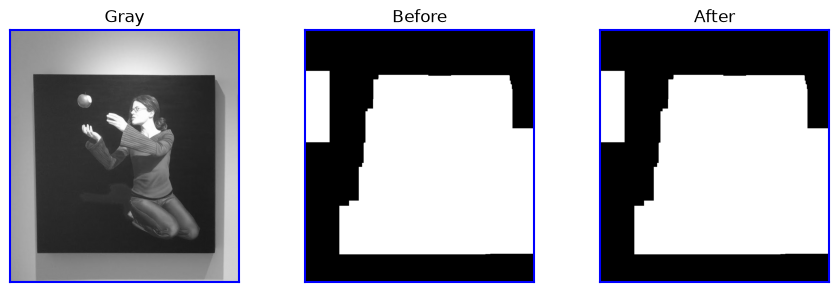

In [702]:
n = int(min(h,w)/10)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (n,n))

last_mask = mask.copy()
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

show(gray, last_mask, mask, titles=['Gray', 'Before', 'After'])

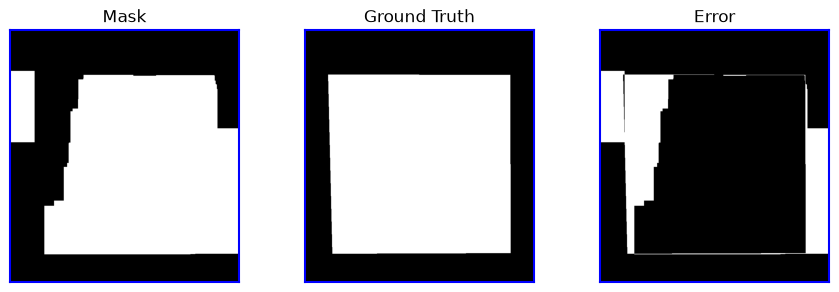

In [703]:
gt = cv2.imread(QSD2 / (IMG_ID+'.png'), cv2.IMREAD_GRAYSCALE)

err = cv2.absdiff(mask, gt)

show(mask, gt, err, titles=['Mask', 'Ground Truth', 'Error'])